# RNA to Protein Multimodal Autoencoder — Per-Variety Analysis

**For designs where each variety has its own samples AND its own gene/protein set.**

```
Variety A: 2 treatments x 4 timepoints x 3 reps = 24 samples, gene set A
Variety B: 2 treatments x 4 timepoints x 3 reps = 24 samples, gene set B
```

Because the two varieties do not share a feature space, they are fitted
**independently** and compared afterwards at the level of orthologous genes.

> `leave_variety_out` (train on A, predict B) is **not possible** here and has
> been removed. Its replacement is `leave_treatment_out` within each variety,
> plus the cross-variety result comparison in section 9.

This notebook runs both varieties in one pass. Run cells top to bottom.

## 0 - Setup

In [1]:
# !pip install torch scikit-learn pandas numpy scipy matplotlib seaborn -q

import sys, os, json, warnings
warnings.filterwarnings("ignore")

PROJ = os.getcwd()
if PROJ not in sys.path:
    sys.path.insert(0, PROJ)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from IPython.display import display

sns.set_theme(style="ticks", font_scale=1.05)
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"python {sys.version.split()[0]} | torch {torch.__version__} | pandas {pd.__version__}")

python 3.10.12 | torch 2.13.0+cu130 | pandas 2.3.3


## 1 - Configuration

Edit this cell only. Everything downstream reads from it.

Parameters are already scaled for **n = 24 per variety**, which is half what a
pooled analysis would have had. Do not raise `LATENT` above ~8: with 8 design
cells (2 treatments x 4 timepoints) a larger latent space simply memorises them.

In [2]:
# =========================================================================
#                            EDIT THIS BLOCK
# =========================================================================

# --- One entry per variety. Set to None to run the synthetic demo. --------
VARIETIES = {
    "A": dict(rna="A_rna.csv", prot="A_prot.csv",
              meta="A_meta.csv", mapping="A_map.csv"),
    "B": dict(rna="B_rna.csv", prot="B_prot.csv",
              meta="B_meta.csv", mapping="B_map.csv"),
}
USE_DEMO = True          # <- set False once your paths above are real

# --- Ortholog map linking variety A protein IDs to variety B protein IDs --
ORTHOLOG_CSV = None      # e.g. "orthologs_A_to_B.csv", columns: id_a, id_b
                         # None -> per-variety results only, no gene-level comparison

# --- Preprocessing (n = 24: keep these small) -----------------------------
N_RNA      = 1500
N_PROT     = 800
RNA_MODE   = "counts"       # "counts" -> CPM+log2 | "logged" -> already normalised
PROT_MODE  = "intensity"    # "intensity" -> log2  | "logged" -> already logged

# --- Autoencoder ----------------------------------------------------------
LATENT       = 6
HIDDEN       = (64, 16)
DROPOUT      = 0.20
EPOCHS       = 400
PATIENCE     = 60
LR           = 1e-3
WEIGHT_DECAY = 3e-3

W_RECON = 0.5     # RNA->RNA and protein->protein reconstruction
W_CROSS = 3.0     # RNA->protein  (the term that produces the discordance score)
W_ALIGN = 0.5     # ||z_rna - z_protein||

# --- Cross-validation -----------------------------------------------------
SPLIT_SCHEMES_WANTED = ["leave_condition_out", "leave_treatment_out"]
#   leave_condition_out  8 folds, holds out 3 reps of a treatment x timepoint cell
#   leave_treatment_out  2 folds, train on control -> predict treated
#   leave_timepoint_out  4 folds, temporal extrapolation
#   naive_random         diagnostic only, shows replicate leakage

# Covariates: ONE function used by CV, the full-data refit and the lag
# analysis alike. Mixing two different ones (4 cols vs 7) makes the CV
# model and the interpretation model non-comparable.
from rnaprot.multivariety import covariate_matrix_single
COVARIATE_FN = covariate_matrix_single      # 7 cols (with interactions)
# For the discordance analysis specifically, consider covariate_matrix_none
# so the residual means 'not explained by RNA' rather than
# 'not explained by RNA + the design you are about to test against'.

N_PERM = 2        # label permutations (raise to 5+ for publication)

# =========================================================================
OUT_DIR = Path("results_per_variety")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)

MODEL_ORDER = ["mean", "design_only", "cognate_ridge", "pca_ridge", "pls", "multimodal_ae"]
PALETTE     = dict(zip(MODEL_ORDER, sns.color_palette("Set2", 6)))
LABELS      = list(VARIETIES)

print("config loaded")
print(f"  varieties : {LABELS}")
print(f"  latent={LATENT} hidden={HIDDEN} n_rna={N_RNA} n_prot={N_PROT}")
print(f"  splits    : {SPLIT_SCHEMES_WANTED}")

config loaded
  varieties : ['A', 'B']
  latent=6 hidden=(64, 16) n_rna=1500 n_prot=800
  splits    : ['leave_condition_out', 'leave_treatment_out']


## 2 - Load each variety

Nothing is merged or reindexed. Each variety keeps its own gene and protein
universe, and each gets its own preprocessing, its own CV, and its own model.

In [3]:
from rnaprot.multivariety import load_variety, SPLIT_SCHEMES_SINGLE, covariate_matrix_single

DATA, TRUTH = {}, {}

if USE_DEMO:
    from rnaprot.simulate import simulate
    for i, lab in enumerate(LABELS):
        d, t = simulate(n_genes=4000, n_prot=800, n_var=1, seed=i)
        d.meta = d.meta.assign(variety=lab)
        # give each variety its own namespace so nothing accidentally lines up
        d.rna.columns  = [f"{lab}_{g}" for g in d.rna.columns]
        d.prot.columns = [f"{lab}_{p}" for p in d.prot.columns]
        d.cognate = {f"{lab}_{p}": f"{lab}_{g}" for p, g in d.cognate.items()}
        t.index = [f"{lab}_{p}" for p in t.index]
        DATA[lab], TRUTH[lab] = d, t

    # trivial ortholog map for the demo (protN in A <-> protN in B)
    common = [p.split("_", 1)[1] for p in DATA[LABELS[0]].prot.columns][:600]
    pd.DataFrame({"id_a": [f"{LABELS[0]}_{p}" for p in common],
                  "id_b": [f"{LABELS[1]}_{p}" for p in common]}) \
      .to_csv(OUT_DIR / "demo_orthologs.csv", index=False)
    ORTHOLOG_CSV = str(OUT_DIR / "demo_orthologs.csv")
    print("SYNTHETIC demo data. The two varieties are simulated from different")
    print("seeds, so there is no shared biology - the cross-variety comparison")
    print("in section 9 should correctly come back null. That is the calibration.")
else:
    for lab, paths in VARIETIES.items():
        DATA[lab] = load_variety(paths["rna"], paths["prot"], paths["meta"],
                                 paths.get("mapping"), variety_label=lab)
        TRUTH[lab] = None
    print("REAL data loaded.")

print()
for lab, d in DATA.items():
    print(f"--- variety {lab} ---")
    print(d.describe())
    if d.n_samples != 24:
        print(f"  note: expected 24 samples, got {d.n_samples}")
    print()

SYNTHETIC demo data. The two varieties are simulated from different
seeds, so there is no shared biology - the cross-variety comparison
in section 9 should correctly come back null. That is the calibration.

--- variety A ---
24 samples | 4,000 genes | 800 proteins
  varieties : ['A']
  treatments: ['T0', 'T1']
  timepoints: ['t0', 't1', 't2', 't3']
  replicates: ['r0', 'r1', 'r2']
  cognate pairs mapped: 800

--- variety B ---
24 samples | 4,000 genes | 800 proteins
  varieties : ['B']
  treatments: ['T0', 'T1']
  timepoints: ['t0', 't1', 't2', 't3']
  replicates: ['r0', 'r1', 'r2']
  cognate pairs mapped: 800



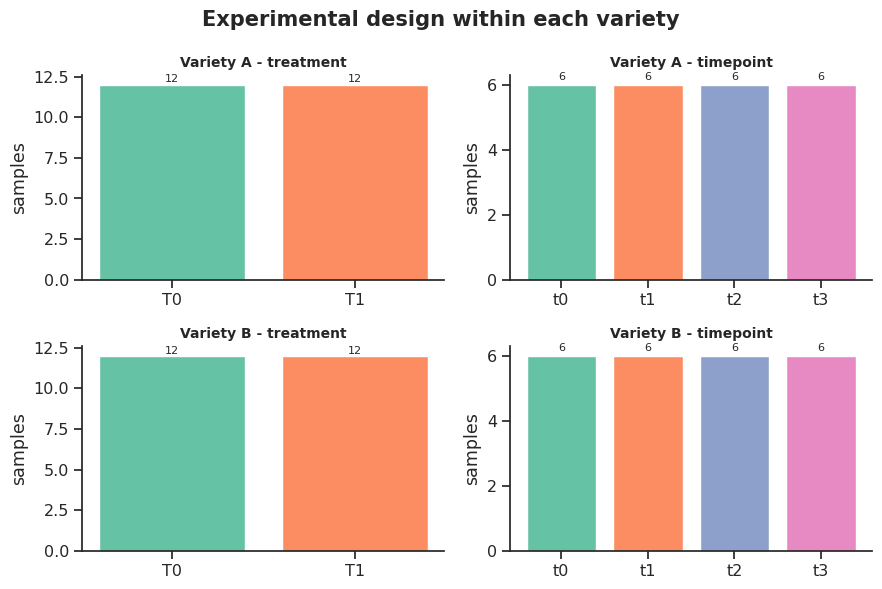

In [4]:
# --- design check, per variety -------------------------------------------
fig, axes = plt.subplots(len(LABELS), 2, figsize=(9, 3.0 * len(LABELS)), squeeze=False)
for r, lab in enumerate(LABELS):
    m = DATA[lab].meta
    for c, col in enumerate(["treatment", "timepoint"]):
        ax = axes[r][c]
        counts = m[col].value_counts().sort_index()
        bars = ax.bar(counts.index, counts.values,
                      color=sns.color_palette("Set2", len(counts)))
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.15,
                    str(int(b.get_height())), ha="center", fontsize=8)
        ax.set_title(f"Variety {lab} - {col}", fontweight="bold", fontsize=10)
        ax.set_ylabel("samples")
        ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Experimental design within each variety", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "design.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 - Preprocessing

Fit separately per variety. Library sizes and variance filters are computed
within a variety because the two assemblies have different gene counts and the
CPM denominators are not comparable across them.

Inside cross-validation this is refit on training samples only, so nothing
leaks. The cell below fits on all 24 samples purely so you can eyeball the
filtering before committing.

variety A: 4,000 genes -> 1,500 | 800 proteins -> 800 | 7 covariates
variety B: 4,000 genes -> 1,500 | 800 proteins -> 800 | 7 covariates


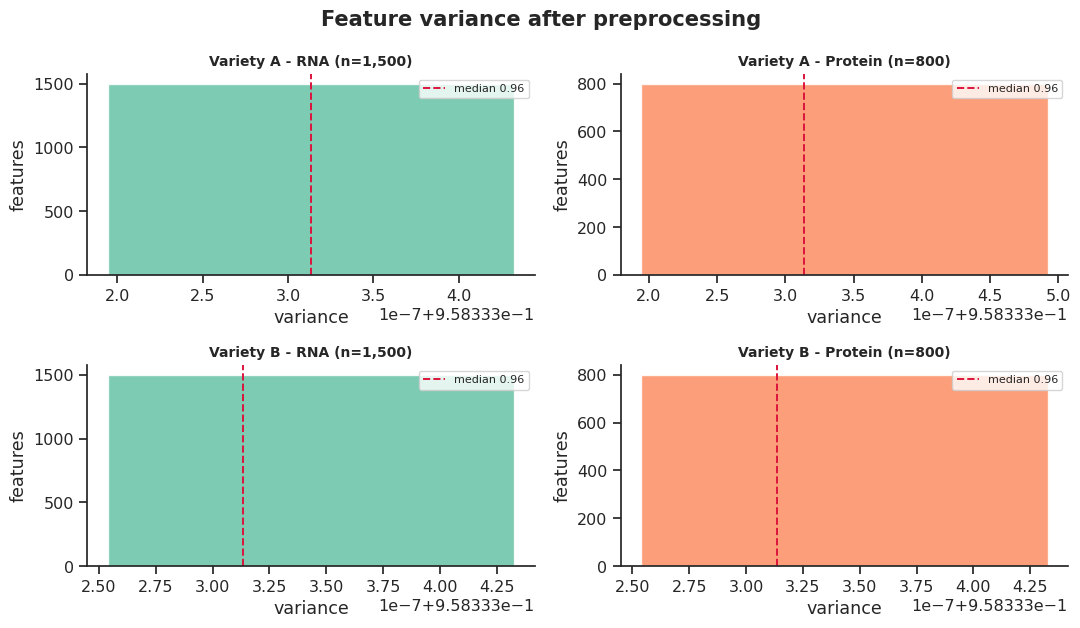

In [5]:
from rnaprot.data import OmicsPreprocessor

PRE, RMAT, PMAT, COV = {}, {}, {}, {}

for lab in LABELS:
    d = DATA[lab]
    pre = OmicsPreprocessor(n_rna=N_RNA, n_prot=N_PROT,
                            rna_mode=RNA_MODE, prot_mode=PROT_MODE) \
          .fit(d, np.arange(d.n_samples))
    R, P = pre.transform(d)
    PRE[lab], RMAT[lab], PMAT[lab] = pre, R, P
    COV[lab] = COVARIATE_FN(d.meta)
    print(f"variety {lab}: {d.rna.shape[1]:,} genes -> {R.shape[1]:,} | "
          f"{d.prot.shape[1]:,} proteins -> {P.shape[1]:,} | "
          f"{COV[lab].shape[1]} covariates")

fig, axes = plt.subplots(len(LABELS), 2, figsize=(11, 3.2 * len(LABELS)), squeeze=False)
for r, lab in enumerate(LABELS):
    for c, (mat, name) in enumerate([(RMAT[lab], "RNA"), (PMAT[lab], "Protein")]):
        ax = axes[r][c]
        var = mat.var(axis=0)
        try:
            counts, edges = np.histogram(var, bins="fd")
        except Exception:
            lo, hi = float(var.min()), float(var.max()) + 1e-9
            counts, edges = np.histogram(var, bins=30, range=(lo, hi))
        ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge",
               color=sns.color_palette("Set2")[c], alpha=0.85)
        ax.axvline(float(np.median(var)), color="crimson", lw=1.4, ls="--",
                   label=f"median {np.median(var):.2f}")
        ax.set_title(f"Variety {lab} - {name} (n={mat.shape[1]:,})",
                     fontweight="bold", fontsize=10)
        ax.set_xlabel("variance"); ax.set_ylabel("features")
        ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Feature variance after preprocessing", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "variance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 - Cross-validation, per variety

Six models on identical folds within each variety.

| model | uses RNA? | why it is here |
|---|---|---|
| `mean` | no | defines R2 = 0 |
| `design_only` | **no** | if this matches your AE, the model learned the design, not biology |
| `cognate_ridge` | own transcript | the textbook answer |
| `pca_ridge` | yes | best linear latent model |
| `pls` | yes | supervised latent components, DIABLO family |
| `multimodal_ae` | yes | your autoencoder |

`leave_treatment_out` is worth reading carefully. It trains on control and
predicts treated. **A failure there is a biological result**, not a modelling
failure: it means treatment altered the RNA to protein mapping.

In [6]:
from rnaprot import baselines as B
from rnaprot.models import AERegressor
from rnaprot.evaluate import run_cv, oof_r2_table, compare_models

def make_cognate_index_fn(cognate):
    def fn(pre):
        gpos = {g: i for i, g in enumerate(pre.rna_features_)}
        return np.array([gpos.get(cognate.get(p), -1) for p in pre.prot_features_])
    return fn

def build_models():
    def ae_factory(ctx):
        return AERegressor(latent=LATENT, hidden=HIDDEN, dropout=DROPOUT,
                           epochs=EPOCHS, patience=PATIENCE, lr=LR,
                           weight_decay=WEIGHT_DECAY,
                           weights=(W_RECON, W_RECON, W_CROSS, W_ALIGN),
                           groups=ctx.get("train_groups"))
    return {
        "mean":          lambda ctx: B.MeanBaseline(),
        "design_only":   lambda ctx: B.DesignBaseline(),
        "cognate_ridge": lambda ctx: B.CognateBaseline(ctx["pairs"]),
        "pca_ridge":     lambda ctx: B.PCARidge(n_components=6),
        "pls":           lambda ctx: B.PLSBaseline(n_components=4),
        "multimodal_ae": ae_factory,
    }

PRE_KW = dict(n_rna=N_RNA, n_prot=N_PROT, rna_mode=RNA_MODE, prot_mode=PROT_MODE)
R2, OOF, FOLDS = {}, {}, {}

for lab in LABELS:
    d = DATA[lab]
    cog_fn = make_cognate_index_fn(d.cognate)
    R2[lab], OOF[lab], fl = {}, {}, []
    for scheme in SPLIT_SCHEMES_WANTED:
        print(f"[variety {lab}] {scheme}")
        splits = SPLIT_SCHEMES_SINGLE[scheme](d.meta)
        folds, oof = run_cv(d, splits, build_models(), PRE_KW, cog_fn,
                            covariate_fn=COVARIATE_FN, verbose=False)
        folds["split_scheme"] = scheme; folds["variety"] = lab
        fl.append(folds)
        t = oof_r2_table(oof)
        vdir = OUT_DIR / lab; (vdir / "figures").mkdir(parents=True, exist_ok=True)
        t.to_csv(vdir / f"per_protein_r2_{scheme}.csv")
        R2[lab][scheme], OOF[lab][scheme] = t, oof
        print(f"   median R2: " +
              ", ".join(f"{m}={t[m].median():.3f}" for m in MODEL_ORDER if m in t))
    FOLDS[lab] = pd.concat(fl)
    FOLDS[lab].to_csv(OUT_DIR / lab / "cv_folds.csv", index=False)

MAIN = SPLIT_SCHEMES_WANTED[0]
print("\ndone")

[variety A] leave_condition_out
   median R2: mean=0.000, design_only=0.076, cognate_ridge=0.185, pca_ridge=0.210, pls=0.206, multimodal_ae=0.001
[variety A] leave_treatment_out
   median R2: mean=0.000, design_only=0.072, cognate_ridge=0.117, pca_ridge=0.096, pls=0.088, multimodal_ae=-0.064
[variety B] leave_condition_out
   median R2: mean=0.000, design_only=0.055, cognate_ridge=0.135, pca_ridge=0.214, pls=0.205, multimodal_ae=0.021
[variety B] leave_treatment_out
   median R2: mean=0.000, design_only=0.062, cognate_ridge=0.096, pca_ridge=0.070, pls=0.062, multimodal_ae=-0.064

done


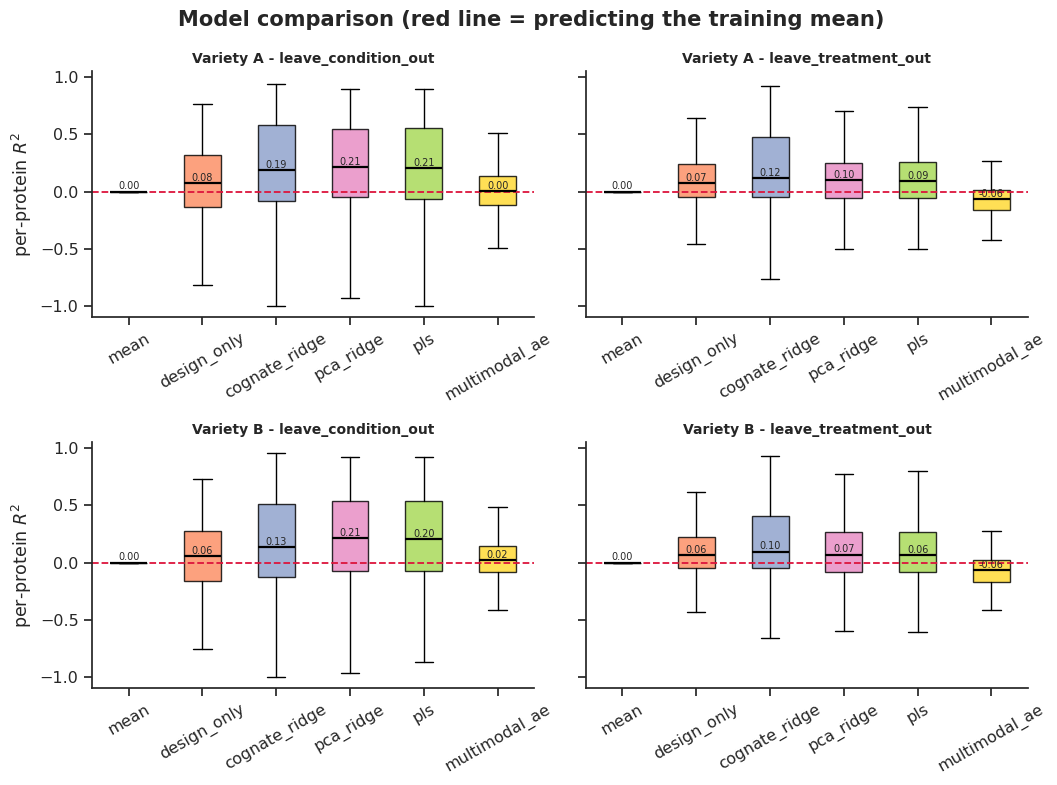

In [7]:
# --- model comparison, one row per variety -------------------------------
n_s = len(SPLIT_SCHEMES_WANTED)
fig, axes = plt.subplots(len(LABELS), n_s, figsize=(5.4 * n_s, 4.0 * len(LABELS)),
                         squeeze=False, sharey=True)
for r, lab in enumerate(LABELS):
    for c, scheme in enumerate(SPLIT_SCHEMES_WANTED):
        ax = axes[r][c]
        t = R2[lab][scheme]
        cols = [m for m in MODEL_ORDER if m in t]
        bp = ax.boxplot([t[m].dropna().clip(-1, 1).values for m in cols],
                        tick_labels=cols, patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.6))
        for patch, m in zip(bp["boxes"], cols):
            patch.set_facecolor(PALETTE[m]); patch.set_alpha(0.82)
        ax.axhline(0, color="crimson", lw=1.3, ls="--")
        ax.set_title(f"Variety {lab} - {scheme}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=30)
        ax.spines[["top", "right"]].set_visible(False)
        for i, m in enumerate(cols):
            ax.text(i + 1, t[m].dropna().clip(-1, 1).median() + 0.02,
                    f"{t[m].median():.2f}", ha="center", fontsize=7)
    axes[r][0].set_ylabel("per-protein $R^2$")
fig.suptitle("Model comparison (red line = predicting the training mean)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# --- paired tests vs pca_ridge -------------------------------------------
for lab in LABELS:
    comp = compare_models(R2[lab][MAIN], reference="pca_ridge")
    comp.to_csv(OUT_DIR / lab / "model_comparison.csv", index=False)
    print(f"=== variety {lab} ({MAIN}) ===")
    display(comp[["model", "median_r2", "median_ref", "median_delta",
                  "win_frac", "wilcoxon_p"]].round(4))

print("median_delta > 0 -> beats pca_ridge on more than half the proteins")
print("At n = 24, expect multimodal_ae to lose. Report it; do not tune until it wins.")

=== variety A (leave_condition_out) ===


,model,median_r2,median_ref,median_delta,win_frac,wilcoxon_p
2,cognate_ridge,0.1855,0.2104,0.0410,0.5550,0.2729
3,pls,0.2063,0.2104,0.0026,0.5425,0.1783
1,design_only,0.0759,0.2104,-0.1053,0.3488,0.0000
0,mean,0.0000,0.2104,-0.2104,0.2950,0.0000
4,multimodal_ae,0.0015,0.2104,-0.2240,0.2500,0.0000


=== variety B (leave_condition_out) ===


,model,median_r2,median_ref,median_delta,win_frac,wilcoxon_p
2,cognate_ridge,0.1347,0.2139,0.0117,0.5200,0.5416
3,pls,0.2047,0.2139,0.0022,0.5337,0.5876
1,design_only,0.0552,0.2139,-0.1116,0.3300,0.0000
4,multimodal_ae,0.0211,0.2139,-0.1821,0.2862,0.0000
0,mean,0.0000,0.2139,-0.2139,0.3175,0.0000


median_delta > 0 -> beats pca_ridge on more than half the proteins
At n = 24, expect multimodal_ae to lose. Report it; do not tune until it wins.


## 5 - Permutation null

Shuffles the protein matrix and reruns the whole CV. Anything surviving this is
a fitting artefact. At n = 24 this control matters more than at n = 48, not
less.

[variety A] 2 permutations ...
               perm0  perm1
mean           0.000  0.000
design_only   -0.118 -0.056
cognate_ridge -0.145 -0.104
pca_ridge     -0.115 -0.168
pls           -0.123 -0.205
multimodal_ae -0.082 -0.103

[variety B] 2 permutations ...
               perm0  perm1
mean           0.000  0.000
design_only   -0.131 -0.076
cognate_ridge -0.158 -0.117
pca_ridge     -0.138 -0.126
pls           -0.143 -0.199
multimodal_ae -0.071 -0.061



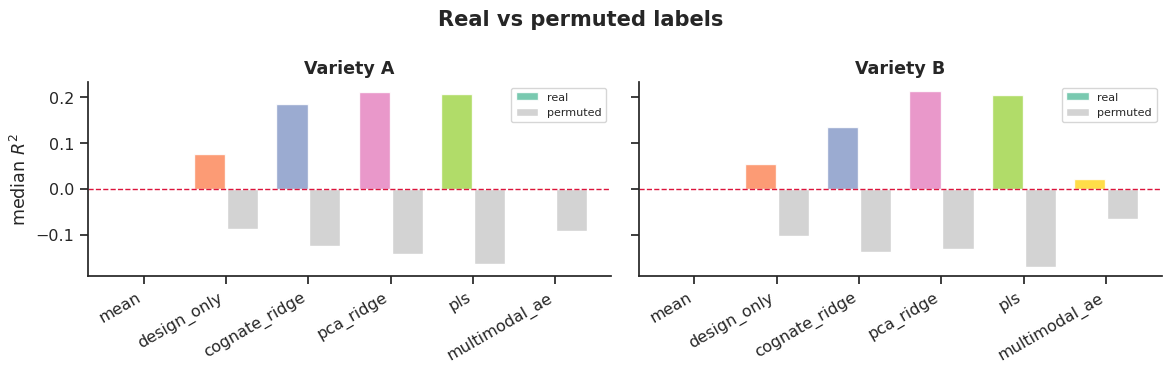

In [9]:
from rnaprot.evaluate import permutation_null

NULL = {}
if N_PERM > 0:
    for lab in LABELS:
        d = DATA[lab]
        print(f"[variety {lab}] {N_PERM} permutations ...")
        NULL[lab] = permutation_null(d, SPLIT_SCHEMES_SINGLE[MAIN](d.meta),
                                     build_models(), n_perm=N_PERM,
                                     pre_kwargs=PRE_KW,
                                     cognate_index_fn=make_cognate_index_fn(d.cognate),
                                     covariate_fn=COVARIATE_FN)
        NULL[lab].to_csv(OUT_DIR / lab / "permutation_null.csv")
        print(NULL[lab].round(3).to_string())
        print()

    fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 3.8),
                             squeeze=False, sharey=True)
    for c, lab in enumerate(LABELS):
        ax = axes[0][c]
        real = {m: R2[lab][MAIN][m].median() for m in MODEL_ORDER if m in R2[lab][MAIN]}
        nullm = NULL[lab].mean(axis=1)
        x = np.arange(len(real))
        ax.bar(x - 0.2, list(real.values()), 0.38, label="real",
               color=[PALETTE[m] for m in real], alpha=0.88)
        ax.bar(x + 0.2, [nullm.get(m, 0) for m in real], 0.38, label="permuted",
               color="lightgray")
        ax.set_xticks(x); ax.set_xticklabels(list(real), rotation=30, ha="right")
        ax.axhline(0, color="crimson", lw=1, ls="--")
        ax.set_title(f"Variety {lab}", fontweight="bold")
        ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
    axes[0][0].set_ylabel("median $R^2$")
    fig.suptitle("Real vs permuted labels", fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / "permutation.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("N_PERM = 0, skipped")

## 6 - RNA to protein discordance

`D = observed protein - protein predicted from RNA`, out-of-fold, then a
per-protein F-test for treatment dependence with BH correction.

- large but **random** D = measurement noise
- D that **tracks treatment** = post-transcriptional regulation

This is the analysis most likely to survive at n = 24, and the one I would build
the paper on.

In [10]:
from rnaprot.evaluate import discordance_table, classify_kinetics

DISC, DMAT, CLUST, PROF = {}, {}, {}, {}

for lab in LABELS:
    disc, D = discordance_table(OOF[lab][MAIN], DATA[lab].meta, model="multimodal_ae")
    if TRUTH.get(lab) is not None:
        disc = disc.join(TRUTH[lab]["truth_class"])
    disc.sort_values("q_value").to_csv(OUT_DIR / lab / "discordance.csv")
    D.to_csv(OUT_DIR / lab / "discordance_matrix.csv")
    clusters, prof = classify_kinetics(D, DATA[lab].meta, n_clusters=5)
    clusters.to_frame().join(disc).to_csv(OUT_DIR / lab / "kinetic_clusters.csv")
    DISC[lab], DMAT[lab], CLUST[lab], PROF[lab] = disc, D, clusters, prof
    n_sig = int((disc["q_value"] < 0.05).sum())
    print(f"variety {lab}: {n_sig}/{len(disc)} proteins with treatment-dependent "
          f"residuals at FDR 5%")

print()
display(DISC[LABELS[0]].sort_values("q_value").head(8).round(3))

variety A: 327/800 proteins with treatment-dependent residuals at FDR 5%
variety B: 297/800 proteins with treatment-dependent residuals at FDR 5%



,mean_abs_discordance,discordance_sd,F_stat,p_value,q_value,explained_var_by_rna,truth_class
A_prot00592,1.081,1.467,79.865,0.0,0.0,-0.181,protein_only
A_prot00340,1.089,1.569,76.814,0.0,0.0,-0.154,protein_only
A_prot00142,1.113,1.650,85.912,0.0,0.0,-0.009,protein_only
A_prot00103,1.014,1.300,73.769,0.0,0.0,0.047,protein_only
A_prot00107,1.115,1.694,67.725,0.0,0.0,-0.057,protein_only
A_prot00694,1.105,1.474,67.404,0.0,0.0,-0.192,protein_only
A_prot00233,0.986,1.377,67.577,0.0,0.0,-0.071,protein_only
A_prot00217,1.028,1.486,58.494,0.0,0.0,-0.025,protein_only


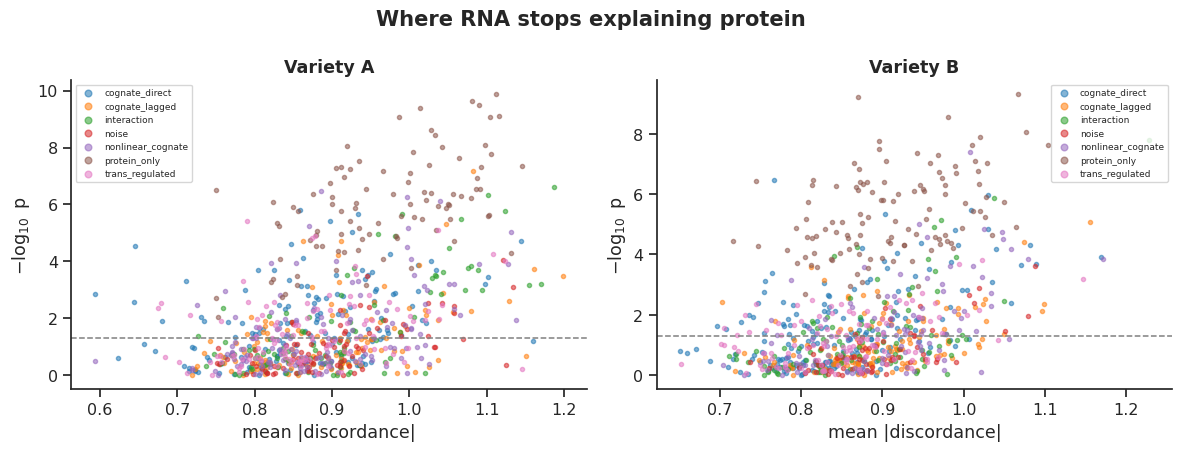

In [11]:
# --- volcano per variety --------------------------------------------------
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 4.6), squeeze=False)
for c, lab in enumerate(LABELS):
    ax = axes[0][c]
    d = DISC[lab]
    y = -np.log10(d["p_value"].clip(1e-300))
    if "truth_class" in d:
        pal = dict(zip(sorted(d["truth_class"].unique()),
                       sns.color_palette("tab10", d["truth_class"].nunique())))
        for cls, g in d.groupby("truth_class"):
            ax.scatter(g["mean_abs_discordance"],
                       -np.log10(g["p_value"].clip(1e-300)),
                       s=9, alpha=0.55, label=cls, color=pal[cls])
        ax.legend(fontsize=6.5, markerscale=1.6)
    else:
        sig = d["q_value"] < 0.05
        ax.scatter(d.loc[~sig, "mean_abs_discordance"], y[~sig], s=8,
                   alpha=0.4, color="lightsteelblue", label="ns")
        ax.scatter(d.loc[sig, "mean_abs_discordance"], y[sig], s=10,
                   alpha=0.75, color="crimson", label="FDR < 5%")
        ax.legend(fontsize=8)
    ax.axhline(-np.log10(0.05), ls="--", color="grey", lw=1.1)
    ax.set_xlabel("mean |discordance|")
    ax.set_ylabel(r"$-\log_{10}$ p")
    ax.set_title(f"Variety {lab}", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Where RNA stops explaining protein", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "discordance_volcano.png", dpi=150, bbox_inches="tight")
plt.show()

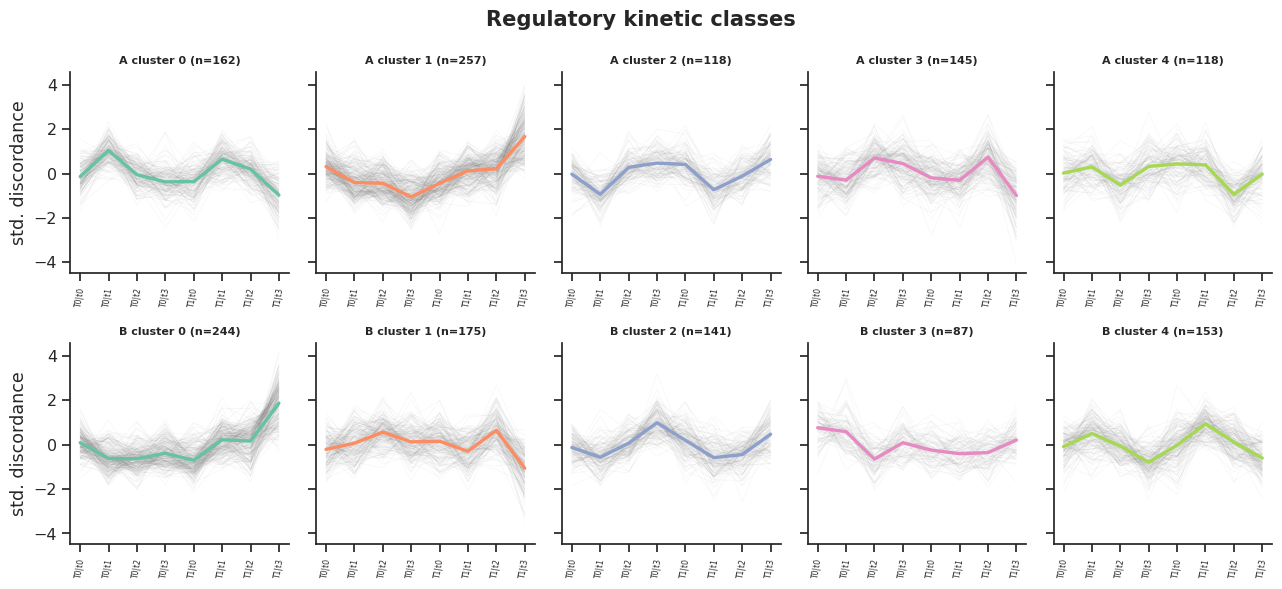

In [12]:
# --- kinetic clusters of residual trajectories ---------------------------
K = CLUST[LABELS[0]].nunique()
fig, axes = plt.subplots(len(LABELS), K, figsize=(2.6 * K, 3.0 * len(LABELS)),
                         squeeze=False, sharey=True)
pal = sns.color_palette("Set2", K)
for r, lab in enumerate(LABELS):
    prof, cl = PROF[lab], CLUST[lab]
    for i in range(K):
        ax = axes[r][i]
        sub = prof.loc[cl[cl == i].index]
        ax.plot(sub.T.to_numpy(), color="grey", alpha=0.07, lw=0.5)
        ax.plot(sub.mean(axis=0).to_numpy(), color=pal[i], lw=2.4)
        ax.set_title(f"{lab} cluster {i} (n={len(sub)})", fontsize=8, fontweight="bold")
        ax.set_xticks(range(prof.shape[1]))
        ax.set_xticklabels(prof.columns, rotation=80, fontsize=5.5)
        ax.spines[["top", "right"]].set_visible(False)
    axes[r][0].set_ylabel("std. discordance")
fig.suptitle("Regulatory kinetic classes", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "kinetic_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 - Latent factors within each variety

Refit on all 24 samples of that variety, purely for interpretation. Each latent
dimension is annotated with the fraction of its variance explained by treatment,
timepoint, and their interaction. The variety term is constant here and drops
out automatically.

In [13]:
from rnaprot.evaluate import latent_design_anova

AE, ZLAT, ANOVA = {}, {}, {}

for lab in LABELS:
    d = DATA[lab]
    print(f"[variety {lab}] fitting on all {d.n_samples} samples ...")
    ae = AERegressor(latent=LATENT, hidden=HIDDEN, dropout=DROPOUT, epochs=EPOCHS,
                     patience=PATIENCE, lr=LR, weight_decay=WEIGHT_DECAY,
                     weights=(W_RECON, W_RECON, W_CROSS, W_ALIGN),
                     groups=d.meta[["treatment", "timepoint"]].astype(str)
                            .agg("|".join, axis=1).to_numpy(),
                     verbose=True).fit(RMAT[lab], PMAT[lab], COV[lab])
    Z = ae.encode(RMAT[lab], COV[lab], "rna")
    pd.DataFrame(Z, index=d.meta.index,
                 columns=[f"z{i+1}" for i in range(Z.shape[1])]) \
      .join(d.meta).to_csv(OUT_DIR / lab / "latent_factors.csv")
    an = latent_design_anova(Z, d.meta.assign(variety="const")) \
         .drop(columns=["variety"], errors="ignore")
    an.to_csv(OUT_DIR / lab / "latent_design_anova.csv")
    AE[lab], ZLAT[lab], ANOVA[lab] = ae, Z, an
    print(f"variety {lab} latent annotation:")
    display(an.round(3))

[variety A] fitting on all 24 samples ...
    [ae] stopped at epoch 76, val cross-MSE 0.9220
variety A latent annotation:


,total_R2,treatment,timepoint,treatment:timepoint
z1,0.899,0.072,0.244,0.153
z2,0.948,0.066,0.617,0.089
z3,0.908,0.178,0.615,0.127
z4,0.963,0.003,0.311,0.282
z5,0.981,0.001,0.456,0.009
z6,0.733,0.173,0.279,0.147


[variety B] fitting on all 24 samples ...
    [ae] stopped at epoch 75, val cross-MSE 0.8508
variety B latent annotation:


,total_R2,treatment,timepoint,treatment:timepoint
z1,0.788,0.000,0.330,0.046
z2,0.931,0.005,0.417,0.104
z3,0.928,0.000,0.496,0.028
z4,0.727,0.008,0.341,0.121
z5,0.820,0.000,0.584,0.066
z6,0.728,0.144,0.477,0.349


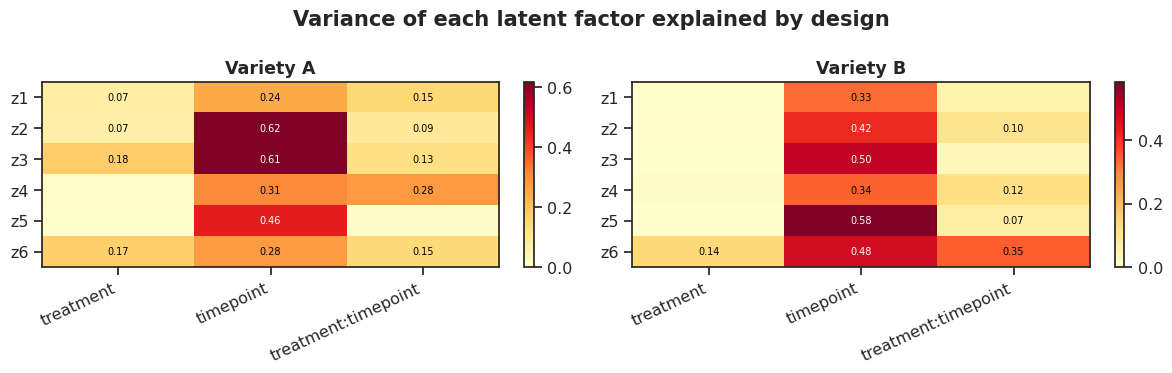

In [14]:
# --- latent x design heatmaps --------------------------------------------
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 3.8), squeeze=False)
for c, lab in enumerate(LABELS):
    an = ANOVA[lab]
    cols = [x for x in an.columns if x != "total_R2"]
    ax = axes[0][c]
    im = ax.imshow(an[cols].to_numpy(), aspect="auto", cmap="YlOrRd", vmin=0,
                   vmax=max(0.05, float(an[cols].to_numpy().max())))
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=25, ha="right")
    ax.set_yticks(range(len(an))); ax.set_yticklabels(an.index)
    ax.set_title(f"Variety {lab}", fontweight="bold")
    for i in range(len(an)):
        for j, cc in enumerate(cols):
            v = an[cols].iloc[i, j]
            if v > 0.05:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if v > 0.35 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Variance of each latent factor explained by design", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "latent_design.png", dpi=150, bbox_inches="tight")
plt.show()

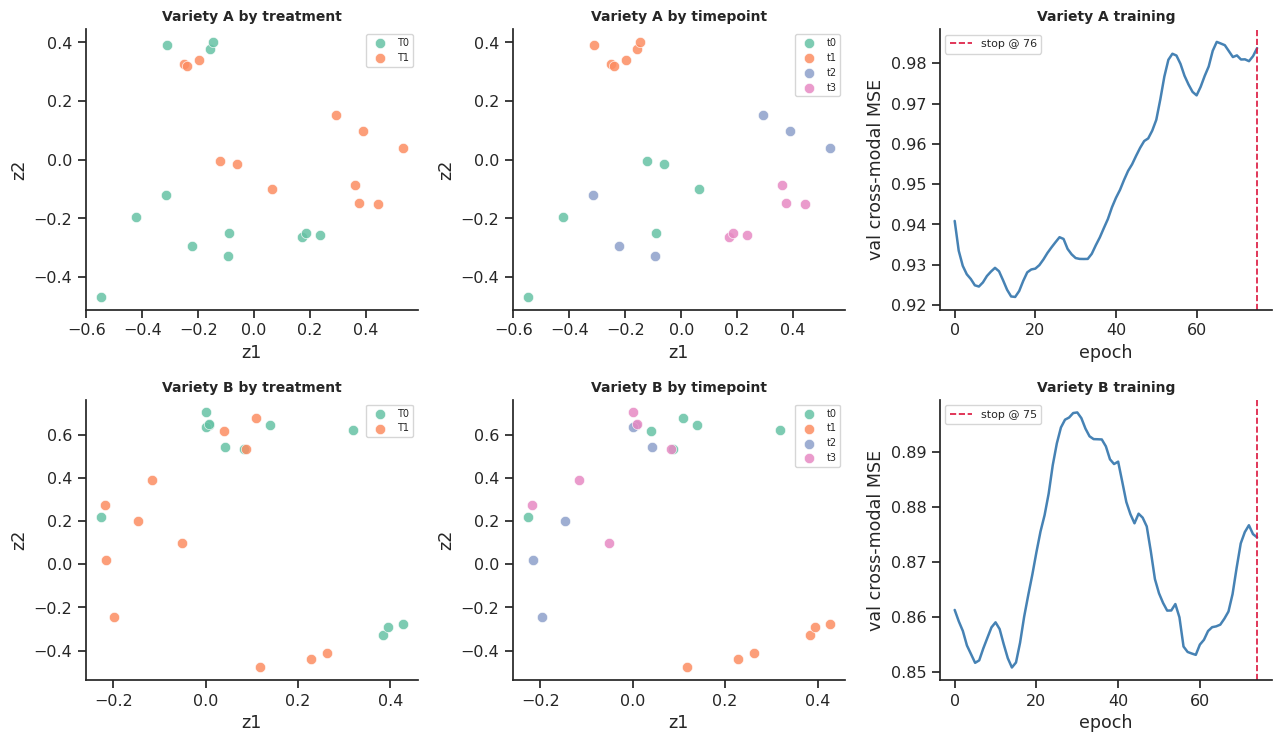

In [15]:
# --- latent scatter + training curves ------------------------------------
fig, axes = plt.subplots(len(LABELS), 3, figsize=(13, 3.8 * len(LABELS)), squeeze=False)
for r, lab in enumerate(LABELS):
    Z, m = ZLAT[lab], DATA[lab].meta
    for c, col in enumerate(["treatment", "timepoint"]):
        ax = axes[r][c]
        grp = m[col].astype(str).to_numpy()
        pal = dict(zip(sorted(set(grp)), sns.color_palette("Set2", len(set(grp)))))
        for gname in sorted(set(grp)):
            s = grp == gname
            ax.scatter(Z[s, 0], Z[s, 1], label=gname, color=pal[gname],
                       s=55, alpha=0.85, edgecolors="white", lw=0.5)
        ax.set_xlabel("z1"); ax.set_ylabel("z2")
        ax.set_title(f"Variety {lab} by {col}", fontweight="bold", fontsize=10)
        ax.legend(fontsize=7); ax.spines[["top", "right"]].set_visible(False)
    ax = axes[r][2]
    ax.plot(AE[lab].history_, color="steelblue", lw=1.8)
    ax.axvline(AE[lab].epochs_run_ - 1, color="crimson", ls="--", lw=1.2,
               label=f"stop @ {AE[lab].epochs_run_}")
    ax.set_xlabel("epoch"); ax.set_ylabel("val cross-modal MSE")
    ax.set_title(f"Variety {lab} training", fontweight="bold", fontsize=10)
    ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "latent_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 - Regulatory lag atlas

Per protein, compare `RNA_t -> protein_t` against `RNA_t -> protein_{t+1}`.

Caveat carried over from the n = 48 validation: proteins with a monotone
temporal trend prefer lag-1 trivially. Cross-filter lag hits against the
discordance table before interpreting them.

In [16]:
# --- leak-free lag analysis (preprocessing refit inside each fold) -------
# Replaces the earlier version, which took R/P/cov from a preprocessor fitted
# to all 24 samples and then split (t, t+1) pairs at random. That leaked both
# through feature selection/scaling and by putting pairs from the SAME
# replicate trajectory on both sides of the split.
from rnaprot.evaluate import lag_cv

LAG = {}
for lab in LABELS:
    print(f"[variety {lab}]")
    LAG[lab] = lag_cv(DATA[lab], PRE_KW, make_cognate_index_fn(DATA[lab].cognate),
                      COVARIATE_FN, lags=(0, 1), seed=SEED)
    if TRUTH.get(lab) is not None:
        LAG[lab] = LAG[lab].join(TRUTH[lab]["truth_class"])
    LAG[lab].sort_values("lag_preference", ascending=False) \
            .to_csv(OUT_DIR / lab / "lag_atlas.csv")
    print(f"  {LAG[lab]['lag_class'].value_counts().to_dict()}")

[variety A]
[lag] lag=0: 24 pairs, median R2=0.222
[lag] lag=1: 18 pairs, median R2=0.258
  {'RNA-first': 318, 'synchronous': 250, 'ambiguous': 232}
[variety B]
[lag] lag=0: 24 pairs, median R2=0.230
[lag] lag=1: 18 pairs, median R2=0.250
  {'RNA-first': 329, 'ambiguous': 275, 'synchronous': 196}


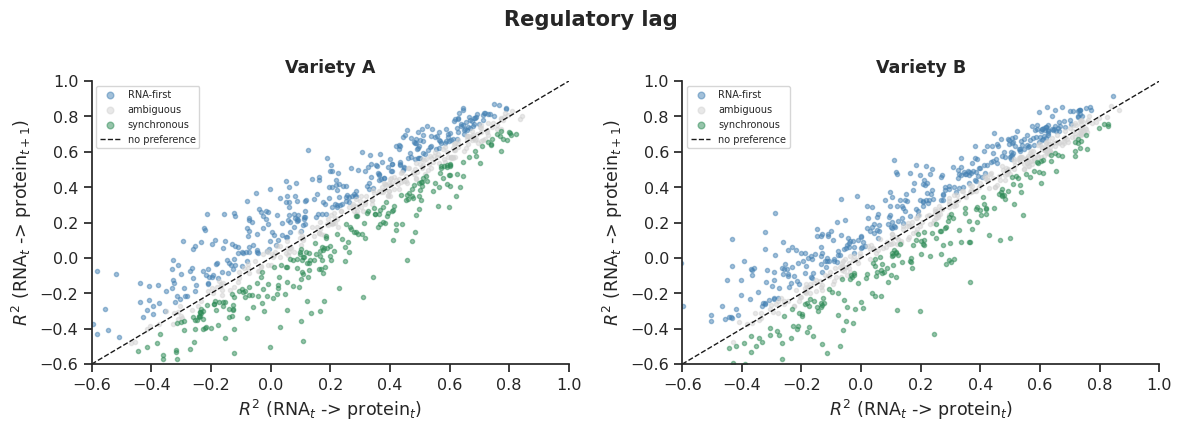

variety A, % RNA-first by planted class:
truth_class
cognate_direct       20.0
cognate_lagged       57.1
interaction          35.7
noise                26.7
nonlinear_cognate    37.7
protein_only         59.1
trans_regulated      47.3

variety B, % RNA-first by planted class:
truth_class
cognate_direct       27.6
cognate_lagged       55.1
interaction          31.4
noise                36.8
nonlinear_cognate    38.4
protein_only         59.8
trans_regulated      42.3



In [17]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 4.4), squeeze=False)
cls_col = {"RNA-first": "steelblue", "synchronous": "seagreen", "ambiguous": "lightgray"}
for c, lab in enumerate(LABELS):
    ax = axes[0][c]; t = LAG[lab]
    for cls, g in t.groupby("lag_class"):
        ax.scatter(g["r2_lag0"].clip(-1, 1), g["r2_lag1"].clip(-1, 1), s=9,
                   alpha=0.5, label=cls, color=cls_col.get(cls, "grey"))
    lim = (-0.6, 1.0)
    ax.plot(lim, lim, "k--", lw=1, label="no preference")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(r"$R^2$ (RNA$_t$ -> protein$_t$)")
    ax.set_ylabel(r"$R^2$ (RNA$_t$ -> protein$_{t+1}$)")
    ax.set_title(f"Variety {lab}", fontweight="bold")
    ax.legend(fontsize=7, markerscale=1.6); ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Regulatory lag", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "lag.png", dpi=150, bbox_inches="tight")
plt.show()

for lab in LABELS:
    if "truth_class" in LAG[lab]:
        pct = (LAG[lab].assign(w=LAG[lab]["lag_class"] == "RNA-first")
                       .groupby("truth_class")["w"].mean() * 100).round(1)
        print(f"variety {lab}, % RNA-first by planted class:")
        print(pct.to_string()); print()

## 9 - Cross-variety comparison

This replaces the lost `leave_variety_out` test.

Two comparisons, one of which needs no ortholog map at all:

1. **Latent factor annotation** (no orthologs) - do both varieties organise
   their variation along the same design axes?
2. **Discordance overlap** (needs orthologs) - are the same orthologous genes
   post-transcriptionally regulated in both?

Fisher exact tests whether the significant sets overlap more than chance.
Spearman on the F statistics is the graded version, robust to where you set the
FDR threshold.

In [18]:
from rnaprot.multivariety import (load_ortholog_map, compare_discordance,
                                   compare_latent_factors, compare_lag)

if len(LABELS) < 2:
    print("only one variety loaded, nothing to compare")
else:
    a, b = LABELS[0], LABELS[1]

    lat = compare_latent_factors(ANOVA[a], ANOVA[b])
    lat.to_csv(OUT_DIR / "cross_variety_latent.csv", index=False)
    print("Latent factor annotation, both varieties (no orthologs needed):")
    display(lat.round(3))

    SUMMARY = {}
    if ORTHOLOG_CSV is None:
        print("ORTHOLOG_CSV is None - skipping gene-level comparison.")
        CROSS = None
    else:
        ortho = load_ortholog_map(ORTHOLOG_CSV)
        print(f"ortholog map: {len(ortho):,} pairs")
        CROSS = compare_discordance(DISC[a], DISC[b], ortho)
        CROSS["merged"].to_csv(OUT_DIR / "cross_variety_discordance.csv", index=False)
        SUMMARY["discordance"] = {k: v for k, v in CROSS.items()
                                  if k not in ("merged", "contingency")}
        SUMMARY["discordance"]["contingency"] = CROSS["contingency"].tolist()
        print(f"  orthologs matched   : {CROSS['n_orthologs']:,}")
        print(f"  conserved (both sig): {CROSS['n_conserved']:,}")
        print(f"  {a}-specific        : {CROSS['n_a_only']:,}")
        print(f"  {b}-specific        : {CROSS['n_b_only']:,}")
        print(f"  Fisher odds={CROSS['fisher_odds']:.2f}  p={CROSS['fisher_p']:.3g}")
        print(f"  Spearman rho={CROSS['spearman_rho']:.3f}  p={CROSS['spearman_p']:.3g}")

        lagres = compare_lag(LAG[a], LAG[b], ortho)
        if lagres["n"]:
            lagres["merged"].to_csv(OUT_DIR / "cross_variety_lag.csv", index=False)
            SUMMARY["lag"] = {k: v for k, v in lagres.items() if k != "merged"}
            print(f"  lag class agreement : {lagres['class_agreement']:.1%}")

        json.dump(SUMMARY, open(OUT_DIR / "cross_variety_summary.json", "w"), indent=2)

Latent factor annotation, both varieties (no orthologs needed):


,term,max_var_explained_A,max_var_explained_B,mean_var_explained_A,mean_var_explained_B
0,treatment,0.178,0.144,0.082,0.026
1,timepoint,0.617,0.584,0.420,0.441
2,treatment:timepoint,0.282,0.349,0.134,0.119


ortholog map: 600 pairs
  orthologs matched   : 600
  conserved (both sig): 91
  A-specific        : 152
  B-specific        : 120
  Fisher odds=1.18  p=0.339
  Spearman rho=0.008  p=0.84
  lag class agreement : 33.3%


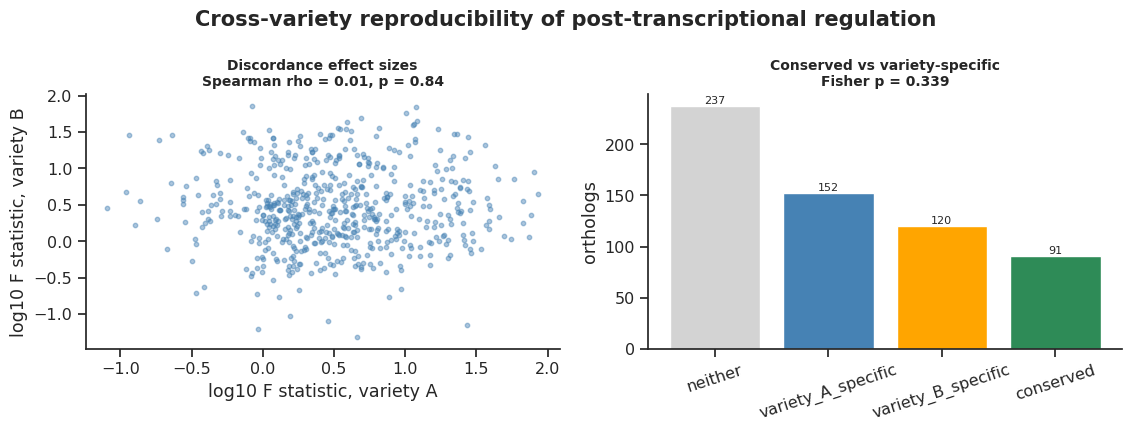

In [19]:
if len(LABELS) >= 2 and CROSS is not None:
    m = CROSS["merged"]
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

    ax = axes[0]
    ax.scatter(np.log10(np.clip(m["F_stat_a"], 1e-3, None)),
               np.log10(np.clip(m["F_stat_b"], 1e-3, None)),
               s=10, alpha=0.45, color="steelblue")
    ax.set_xlabel(f"log10 F statistic, variety {LABELS[0]}")
    ax.set_ylabel(f"log10 F statistic, variety {LABELS[1]}")
    ax.set_title(f"Discordance effect sizes\nSpearman rho = {CROSS['spearman_rho']:.2f}, "
                 f"p = {CROSS['spearman_p']:.2g}", fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    counts = m["class"].value_counts()
    colors = {"conserved": "seagreen", f"variety_A_specific": "steelblue",
              f"variety_B_specific": "orange", "neither": "lightgray"}
    ax.bar(counts.index, counts.values,
           color=[colors.get(k, "grey") for k in counts.index])
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=8)
    ax.set_ylabel("orthologs"); ax.tick_params(axis="x", rotation=18)
    ax.set_title(f"Conserved vs variety-specific\nFisher p = {CROSS['fisher_p']:.3g}",
                 fontweight="bold", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Cross-variety reproducibility of post-transcriptional regulation",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "figures" / "cross_variety.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("no ortholog comparison to plot")

## 10 - Output summary

In [20]:
print(f"outputs -> {OUT_DIR.resolve()}")
print()
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file():
        print(" ", f.relative_to(OUT_DIR))

outputs -> /mnt/integrated-omics/pkg/results_per_variety

  A/cv_folds.csv
  A/discordance.csv
  A/discordance_matrix.csv
  A/kinetic_clusters.csv
  A/lag_atlas.csv
  A/latent_design_anova.csv
  A/latent_factors.csv
  A/model_comparison.csv
  A/per_protein_r2_leave_condition_out.csv
  A/per_protein_r2_leave_treatment_out.csv
  A/permutation_null.csv
  B/cv_folds.csv
  B/discordance.csv
  B/discordance_matrix.csv
  B/kinetic_clusters.csv
  B/lag_atlas.csv
  B/latent_design_anova.csv
  B/latent_factors.csv
  B/model_comparison.csv
  B/per_protein_r2_leave_condition_out.csv
  B/per_protein_r2_leave_treatment_out.csv
  B/permutation_null.csv
  cross_variety_discordance.csv
  cross_variety_lag.csv
  cross_variety_latent.csv
  cross_variety_summary.json
  demo_orthologs.csv
  figures/cross_variety.png
  figures/design.png
  figures/discordance_volcano.png
  figures/kinetic_clusters.png
  figures/lag.png
  figures/latent_design.png
  figures/latent_scatter.png
  figures/model_comparison.png
 

---
## Reading your results

| what you see | what it means | what to do |
|---|---|---|
| `multimodal_ae` loses to `pca_ridge` in both varieties | RNA to protein mapping is essentially linear at this sample size | report the linear model; this is a finding, not a failure |
| `design_only` matches everything | models learned the experimental design, not RNA biology | check preprocessing; RNA may carry little protein-relevant signal |
| `leave_treatment_out` collapses but `leave_condition_out` is fine | treatment altered the RNA to protein mapping | this is a headline biological result, not a bug |
| Fisher p < 0.05, odds > 1 in section 9 | the same orthologs are discordant in both varieties | strong reproducibility claim, lead with it |
| Fisher not significant | variety-specific regulation, **or** underpowered at n = 24 | report the odds ratio alongside the p-value; do not over-read a null |
| permuted R2 close to real R2 | the signal is fitting artefact | stop and investigate before interpreting anything |

**On the demo:** the two synthetic varieties come from different random seeds,
so they share no biology by construction. The cross-variety comparison should
return a null. If it does, your pipeline is calibrated correctly.

**Normalisation reminder:** each variety is normalised independently. Do not
concatenate the count matrices before loading, because the two assemblies have
different gene counts and the CPM denominators are not comparable.